In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch

xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
xlstm_config.step_kernel = "native"
xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
xlstm_config.sequence_kernel = "native_sequence__native"

model = AutoModelForCausalLM.from_pretrained("NX-AI/xLSTM-7b",
                                             config=xlstm_config, device_map="auto")

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")

# Your prompt
prompt = "The quick brown fox jumps over the lazy dog."

# Tokenize and send to the same device as the model
inputs = tokenizer(prompt, return_tensors="pt")['input_ids'].to(model.device)

# Get the BOS token ID from the tokenizer
bos_id = tokenizer.bos_token_id

# Prepend BOS
bos_tensor = torch.tensor([[bos_id]], device=model.device, dtype=inputs.dtype)
tokens_with_bos = torch.cat([bos_tensor, inputs], dim=1)

# Generate
with torch.no_grad():
    outputs = model(tokens_with_bos, output_hidden_states=True)

hidden_states = outputs.hidden_states



d:\A_Facultate\Diseration\logit_lens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 483/483 [00:36<00:00, 13.40it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


In [2]:
print(len(hidden_states))

33


In [3]:
FINAL_NORM = model.backbone.out_norm
LM_HEAD = model.lm_head
INPUT_TOKENS = [tokenizer.decode(t).replace("Ġ", "").replace(" ", "") for t in tokenizer(prompt)['input_ids']]

In [4]:
state=hidden_states[20]
logits = LM_HEAD(FINAL_NORM(state))

final_token_logits = logits[0, -1, :]
# Grab the index with the highest number
best_guess_id = torch.argmax(final_token_logits, dim=-1)
print(tokenizer.decode(best_guess_id))

)[$


In [5]:
def extract_top_tokens(lm_head, final_norm):
    import torch.nn.functional as F
    all_layers_predictions = []
    all_layers_logits = []
    for i, h in enumerate(hidden_states):
        if i % 2: 
            continue

        logits = lm_head(final_norm(hidden_states[i]))
        final_token_logits = logits[0, :-1, :]

        probs = F.softmax(final_token_logits, dim=-1)
        max_logits, best_guess_ids = torch.max(probs, dim=-1)
        layer_tokens = [tokenizer.decode(token_id) for token_id in best_guess_ids]

        all_layers_predictions.append(layer_tokens)
        all_layers_logits.append(max_logits.tolist())

    return all_layers_predictions, all_layers_logits

top_token_per_block, top_logits_per_block = extract_top_tokens(LM_HEAD, FINAL_NORM)


In [6]:
len(top_token_per_block)

17

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_table(top_tokens, top_logits): 
    if not top_tokens or not top_tokens[0]:
        return
        
    num_cols = min(len(top_tokens[0]), len(INPUT_TOKENS))
    if num_cols <= 0:
        print("Sequence too short to align predictions.")
        return
        
    top_headers = INPUT_TOKENS[:num_cols]
    bottom_headers = (["<BOS>"] + INPUT_TOKENS)[:num_cols]
    
    table_data = [row[:num_cols] for row in top_tokens[::-1]] + [bottom_headers]
    logits_data = [row[:num_cols] for row in top_logits[::-1]]
    all_logits = [val for row in logits_data for val in row]
    norm = mcolors.Normalize(vmin=min(all_logits), vmax=max(all_logits))
    import numpy as np
    from matplotlib.colors import ListedColormap
    
    base_cmap = plt.get_cmap('plasma')
    cmap_colors = base_cmap(np.arange(base_cmap.N))
    cmap_colors[:, -1] = 0.75 # Adjust this value (0.0 to 1.0) to change opacity
    cmap = ListedColormap(cmap_colors)
    row_headers = [f"h_{2*i+1:02d}" for i in range(len(top_tokens))][::-1] + ["Input"]
    
    fig, ax = plt.subplots(figsize=(len(top_headers) * 1.2, len(table_data) * 0.5))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(
        cellText=table_data,
        rowLabels=row_headers,
        colLabels=top_headers,
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(table_data) or col == -1: 
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0') 
        else:
            val = logits_data[row-1][col]
            r, g, b, a = cmap(norm(val))
            cell.set_facecolor((r, g, b, a))
            if 0.299*r + 0.587*g + 0.114*b < 0.5:
                cell.get_text().set_color('white')
            
            if col < len(top_headers):
                pred_token = str(table_data[row-1][col]).replace("Ġ", "").replace(" ", "")
                target_token = str(top_headers[col]).replace("Ġ", "").replace(" ", "")
                if pred_token == target_token:
                    cell.set_edgecolor('black')
                    cell.set_linewidth(3)
                    cell.set_zorder(10)
                    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('Confidence (Probability)')
    plt.show()



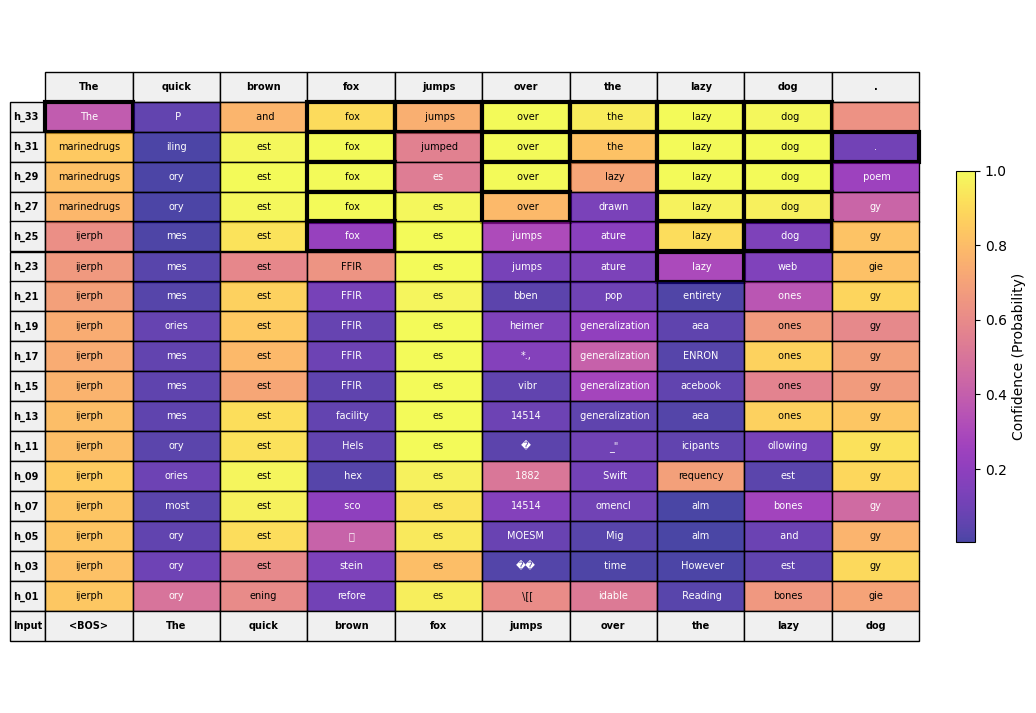

In [11]:
plot_table(top_token_per_block, top_logits_per_block)

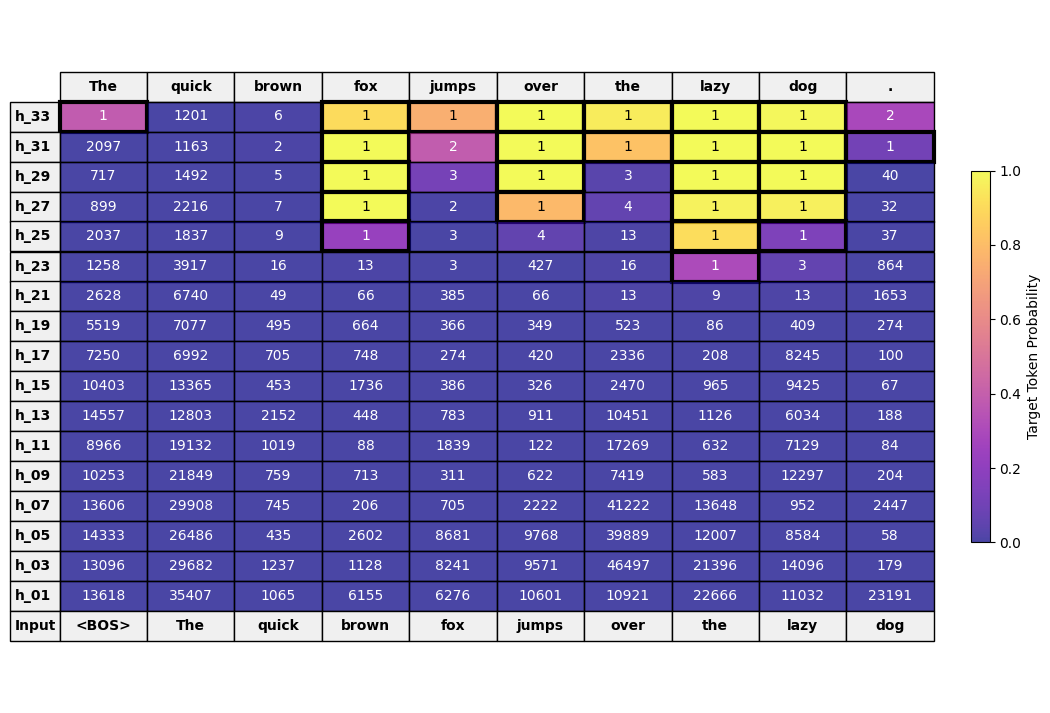

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import ListedColormap

def extract_target_ranks_and_probs(lm_head, final_norm, hidden_states, target_ids):
    all_layers_ranks = []
    all_layers_probs = []
    
    for i, h in enumerate(hidden_states):
        if i % 2: 
            continue

        logits = lm_head(final_norm(hidden_states[i]))
        final_token_logits = logits[0, :-1, :]

        probs = F.softmax(final_token_logits, dim=-1)
        
        sorted_probs, sorted_indices = torch.sort(probs, dim=-1, descending=True)
        
        layer_ranks = []
        layer_probs = []
        
        for pos in range(len(target_ids)):
            target_id = target_ids[pos].item()
            rank = (sorted_indices[pos] == target_id).nonzero(as_tuple=True)[0].item() + 1
            prob = probs[pos, target_id].item()
            
            layer_ranks.append(rank)
            layer_probs.append(prob)

        all_layers_ranks.append(layer_ranks)
        all_layers_probs.append(layer_probs)

    return all_layers_ranks, all_layers_probs

def plot_rank_table(ranks_data, probs_data): 
    if not ranks_data or not ranks_data[0]:
        return
        
    num_cols = min(len(ranks_data[0]), len(INPUT_TOKENS))
    if num_cols <= 0:
        print("Sequence too short to align predictions.")
        return
        
    top_headers = INPUT_TOKENS[:num_cols]
    bottom_headers = (["<BOS>"] + INPUT_TOKENS)[:num_cols]
    
    table_data = [row[:num_cols] for row in ranks_data[::-1]] + [bottom_headers]
    logits_data = [row[:num_cols] for row in probs_data[::-1]]
    all_logits = [val for row in logits_data for val in row]
    
    norm = mcolors.Normalize(vmin=min(all_logits), vmax=max(all_logits))
    
    base_cmap = plt.get_cmap('plasma')
    cmap_colors = base_cmap(np.arange(base_cmap.N))
    cmap_colors[:, -1] = 0.75
    cmap = ListedColormap(cmap_colors)
    
    row_headers = [f"h_{2*i+1:02d}" for i in range(len(ranks_data))][::-1] + ["Input"]
    
    fig, ax = plt.subplots(figsize=(len(top_headers) * 1.2, len(table_data) * 0.5))
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(
        cellText=table_data,
        rowLabels=row_headers,
        colLabels=top_headers,
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(table_data) or col == -1: 
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0') 
        else:
            val = logits_data[row-1][col]
            r, g, b, a = cmap(norm(val))
            cell.set_facecolor((r, g, b, a))
            
            if 0.299*r + 0.587*g + 0.114*b < 0.5:
                cell.get_text().set_color('white')
            
            if col < len(top_headers):
                cell_rank = table_data[row-1][col]
                if str(cell_rank) == "1":
                    cell.set_edgecolor('black')
                    cell.set_linewidth(3)
                    cell.set_zorder(10)
                    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('Target Token Probability')
    plt.show()

target_ids = inputs[0]
ranks_per_block, probs_per_block = extract_target_ranks_and_probs(LM_HEAD, FINAL_NORM, hidden_states, target_ids)
plot_rank_table(ranks_per_block, probs_per_block)